# V3 Social-Signal Prompt Experiment

Goal: test whether a prompt aligned with the VKR methodology improves multilabel social-risk annotation.

Methodological framing:
- news item = unit of observation;
- factor = unit of interpretation;
- news is a weak social signal, not a direct measurement of social reality;
- LLM output remains structured annotation for downstream aggregation and expert review;
- output schema stays compatible: `relevance`, `sentiment`, `pressure`, `confidence`, `evidence`, `reason`.

We do not predict `direct/context/weak` as separate target labels in the main task. They are used as
diagnostic gold strata only: which kind of gold signal does the model catch.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

ROOT = Path.cwd()
OUT = ROOT / "analysis_outputs"
DATASET = OUT / "v3_clean_broad_weak_dataset_1000.csv"

from analyzer.factors import FACTOR_CONFIG
FACTOR_KEYS = [item["key"] for item in FACTOR_CONFIG]
pd.set_option("display.max_colwidth", 140)

## Why batch size mattered

The first social-signal pilot used `batch_size=6` and `max_tokens=8192`.

`max_tokens` is only an upper generation cap. It does not force the model to write 8192 tokens.
The stronger problem was batching: with several news items in one request, the local LLM had to keep
several IDs, texts, factor decisions, evidence strings and JSON objects in memory at once. That increased
schema errors and made the model conservative.

The final runs use `batch_size=1`. This is slower with `thinking=true`, but methodologically cleaner:
each news item gets a full factor checklist.

## Prompt Policy

In [2]:
prompt_policy = [
    "Разметь одну новость как источник слабых социальных сигналов.",
    "Верни все factor_id, с которыми есть содержательная связь; не выбирай один главный класс.",
    "relevance=0.9: прямой/главный сигнал; 0.6: явная связь; 0.3: слабая, но реальная аналитическая связь.",
    "Если релевантная новость дала только 0-1 фактор, перепроверь co-labels.",
    "Проверь группы: безопасность/смертность, медицина, цены/доходы, производство/компании, жилье/ЖКХ, экология, семья/дети, миграция/демография.",
]
count_prior_v4 = [
    "В v3-разметке релевантная новость обычно содержит около 3 релевантных факторов.",
    "Для обычной релевантной новости целевой диапазон 2-4 фактора.",
    "Для комплексной новости про атаку, аварию, бюджет, санкции, промышленность, цены, медицину или ЖКХ допустимо 4-8 факторов.",
    "Лучше вернуть дополнительную потенциальную связь с relevance=0.3, чем пропустить фактор, который потом может быть отфильтрован downstream-верификатором.",
]
co_label_examples = [
    {
        "news": "удар по энергообъекту, погибший и раненые",
        "expected": "crime_count; mortality_rate; life_expectancy; industrial_production_index",
    },
    {
        "news": "авария на водоканале, дома остались без воды",
        "expected": "housing_area_per_capita; wastewater_discharge",
    },
    {
        "news": "бюджет ФОМС и Социального фонда",
        "expected": "hospitals; per_capita_income; living_wage; children_benefits",
    },
    {
        "news": "санкции против энергетической компании",
        "expected": "industrial_production_index; enterprises_count; consumer_price_index only if population prices/tariffs are affected",
    },
    {
        "news": "переговоры РФ-США без перемещения людей",
        "expected": "no international_inflow/outflow only for diplomacy",
    },
]
display(pd.DataFrame({"prompt_policy": prompt_policy}))
display(pd.DataFrame({"explicit_count_prior_tested_in_v4": count_prior_v4}))
display(pd.DataFrame(co_label_examples))

,prompt_policy
0,Разметь одну новость как источник слабых социальных сигналов.
1,"Верни все factor_id, с которыми есть содержательная связь; не выбирай один главный класс."
2,"relevance=0.9: прямой/главный сигнал; 0.6: явная связь; 0.3: слабая, но реальная аналитическая связь."
3,"Если релевантная новость дала только 0-1 фактор, перепроверь co-labels."
4,"Проверь группы: безопасность/смертность, медицина, цены/доходы, производство/компании, жилье/ЖКХ, экология, семья/дети, миграция/демогра..."


,explicit_count_prior_tested_in_v4
0,В v3-разметке релевантная новость обычно содержит около 3 релевантных факторов.
1,Для обычной релевантной новости целевой диапазон 2-4 фактора.
2,"Для комплексной новости про атаку, аварию, бюджет, санкции, промышленность, цены, медицину или ЖКХ допустимо 4-8 факторов."
3,"Лучше вернуть дополнительную потенциальную связь с relevance=0.3, чем пропустить фактор, который потом может быть отфильтрован downstrea..."


,news,expected
0,"удар по энергообъекту, погибший и раненые",crime_count; mortality_rate; life_expectancy; industrial_production_index
1,"авария на водоканале, дома остались без воды",housing_area_per_capita; wastewater_discharge
2,бюджет ФОМС и Социального фонда,hospitals; per_capita_income; living_wage; children_benefits
3,санкции против энергетической компании,industrial_production_index; enterprises_count; consumer_price_index only if population prices/tariffs are affected
4,переговоры РФ-США без перемещения людей,no international_inflow/outflow only for diplomacy


## Run Coverage

In [3]:
run_files = {
    "social_signal_v3_false": OUT / "v3_social_signal_experiment_social_signal_v3_think_false_v3_b1_search237.csv",
    "social_signal_v3_true": OUT / "v3_social_signal_experiment_social_signal_v3_think_true_v3_b1_search237_think.csv",
    "social_signal_v3_false_raw": OUT / "v3_social_signal_experiment_social_signal_v3_think_false_v3_b1_search237.raw.jsonl",
    "social_signal_v3_true_raw": OUT / "v3_social_signal_experiment_social_signal_v3_think_true_v3_b1_search237_think.raw.jsonl",
}
rows = []
for name, path in run_files.items():
    if not path.exists():
        rows.append({"run": name, "exists": False})
        continue
    if path.suffix == ".csv":
        pred = pd.read_csv(path)
        rows.append(
            {
                "run": name,
                "exists": True,
                "rows": len(pred),
                "news_ids": pred["dataset_row_id"].nunique(),
                "positive_rows": int((pd.to_numeric(pred["relevance"], errors="coerce").fillna(0) > 0).sum()),
                "mean_pred_labels_per_news": round(float((pd.to_numeric(pred["relevance"], errors="coerce").fillna(0) > 0).sum() / pred["dataset_row_id"].nunique()), 3),
            }
        )
    else:
        statuses = []
        for line in path.read_text(encoding="utf-8").splitlines():
            statuses.append(json.loads(line).get("status"))
        rows.append(
            {
                "run": name,
                "exists": True,
                "raw_calls": len(statuses),
                "ok_calls": statuses.count("ok"),
                "error_calls": statuses.count("error"),
            }
        )
pd.DataFrame(rows)

,run,exists,rows,news_ids,positive_rows,mean_pred_labels_per_news,raw_calls,ok_calls,error_calls
0,social_signal_v3_false,True,8532.0,237.0,265.0,1.118,NaN,NaN,NaN
1,social_signal_v3_true,True,8532.0,237.0,278.0,1.173,NaN,NaN,NaN
2,social_signal_v3_false_raw,True,NaN,NaN,NaN,NaN,237.0,229.0,8.0
3,social_signal_v3_true_raw,True,NaN,NaN,NaN,NaN,237.0,237.0,0.0


## Main Metrics

In [4]:
metrics = pd.read_csv(OUT / "v3_social_signal_final_comparison_metrics.csv")
main = metrics[metrics["scope"].eq("all")].sort_values("micro_f1", ascending=False)
main[
    [
        "config",
        "gold_pairs",
        "pred_pairs",
        "mean_pred_labels",
        "precision",
        "recall",
        "micro_f1",
        "macro_f1_supported",
        "sample_f1",
        "any_f1",
        "false_relevant",
        "missed_all",
    ]
].round(4)

,config,gold_pairs,pred_pairs,mean_pred_labels,precision,recall,micro_f1,macro_f1_supported,sample_f1,any_f1,false_relevant,missed_all
0,old_union+social_signal_think,656,542,2.2869,0.5775,0.4771,0.5225,0.3595,0.4870,0.9784,10,0
1,old_union+social_signal,656,532,2.2447,0.5752,0.4665,0.5152,0.3562,0.4875,0.9784,10,0
2,latent45+social_think,656,444,1.8734,0.6306,0.4268,0.5091,0.3227,0.4719,0.9784,10,0
3,all_sources_max035_with_social_think,656,480,2.0253,0.5854,0.4284,0.4947,0.3838,0.4460,0.9626,9,8
4,best_old_union,656,468,1.9747,0.5705,0.4070,0.4751,0.3066,0.4439,0.9739,9,3
5,latent_v3@0.30,656,429,1.8101,0.5385,0.3521,0.4258,0.2695,0.3787,0.9784,10,0
6,social_signal_v3_think@0.05,656,278,1.1730,0.7014,0.2973,0.4176,0.2322,0.4037,0.9762,10,1
7,latent_v3@0.45,656,327,1.3797,0.6147,0.3064,0.4090,0.2555,0.3658,0.9417,9,17
8,social_signal_v3@0.05,656,265,1.1181,0.6981,0.2820,0.4017,0.1870,0.4018,0.9605,10,8


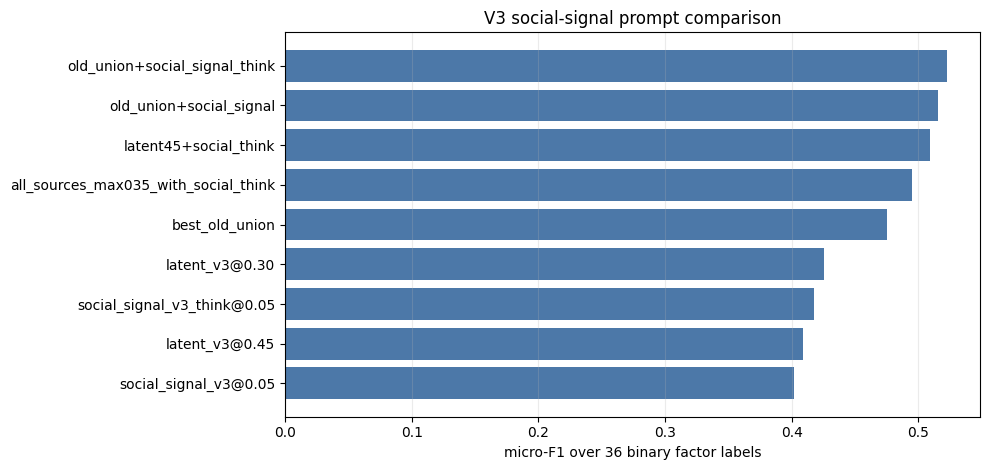

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = main.sort_values("micro_f1").copy()
ax.barh(plot_df["config"], plot_df["micro_f1"], color="#4c78a8")
ax.set_xlabel("micro-F1 over 36 binary factor labels")
ax.set_title("V3 social-signal prompt comparison")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Explicit `~3 Factors Per Relevant News` Prior

In [6]:
v4 = pd.read_csv(OUT / "v3_social_signal_v4_comparison_metrics.csv")
v4[
    [
        "config",
        "gold_pairs",
        "pred_pairs",
        "mean_pred_labels",
        "precision",
        "recall",
        "micro_f1",
        "any_f1",
        "false_relevant",
        "missed_all",
    ]
].round(4)

,config,gold_pairs,pred_pairs,mean_pred_labels,precision,recall,micro_f1,any_f1,false_relevant,missed_all
0,old_union+social_v3_think,656,542,2.2869,0.5775,0.4771,0.5225,0.9784,10,0
1,old_union+social_v3_think+v4,656,563,2.3755,0.5631,0.4832,0.5201,0.9784,10,0
2,old_union+social_v4,656,536,2.2616,0.5634,0.4604,0.5067,0.9784,10,0
3,old_union,656,468,1.9747,0.5705,0.4070,0.4751,0.9739,9,3
4,social_v3_think@0.05,656,278,1.1730,0.7014,0.2973,0.4176,0.9762,10,1
5,social_v3@0.05,656,265,1.1181,0.6981,0.2820,0.4017,0.9605,10,8
6,social_v4@0.05,656,252,1.0633,0.6905,0.2652,0.3833,0.9420,10,16
7,social_v4@0.40,656,192,0.8101,0.7865,0.2302,0.3561,0.8463,2,59


The explicit count prior was tested as `social_signal_v4`.

It did not improve this local model. The model became slower, had more JSON/schema failures, and returned
fewer labels on average. So the lesson is not "never use a count prior"; the lesson is that for this
Gemma run, count pressure inside the prompt is weaker than architectural expansion/reranking.

## Direct / Context / Weak Diagnostics

In [7]:
strength_view = metrics[metrics["scope"].isin(["direct", "context", "weak", "direct_context"])].copy()
display(
    strength_view.sort_values(["scope", "micro_f1"], ascending=[True, False])[
        ["scope", "config", "gold_pairs", "pred_pairs", "precision", "recall", "micro_f1", "any_f1", "missed_all"]
    ].round(4)
)

,scope,config,gold_pairs,pred_pairs,precision,recall,micro_f1,any_f1,missed_all
9,context,latent45+social_think,259,444,0.2095,0.3591,0.2646,0.7592,0
10,context,old_union+social_signal_think,259,542,0.1882,0.3938,0.2547,0.7592,0
11,context,social_signal_v3_think@0.05,259,278,0.2446,0.2625,0.2533,0.7612,0
12,context,old_union+social_signal,259,532,0.1823,0.3745,0.2453,0.7592,0
13,context,all_sources_max035_with_social_think,259,480,0.1792,0.3320,0.2327,0.7668,2
14,context,social_signal_v3@0.05,259,265,0.2226,0.2278,0.2252,0.7380,7
15,context,best_old_union,259,468,0.1688,0.3050,0.2173,0.7619,1
16,context,latent_v3@0.30,259,429,0.1608,0.2664,0.2006,0.7592,0
17,context,latent_v3@0.45,259,327,0.1774,0.2239,0.1980,0.7527,8
18,direct,all_sources_max035_with_social_think,243,480,0.3250,0.6420,0.4315,0.7733,2


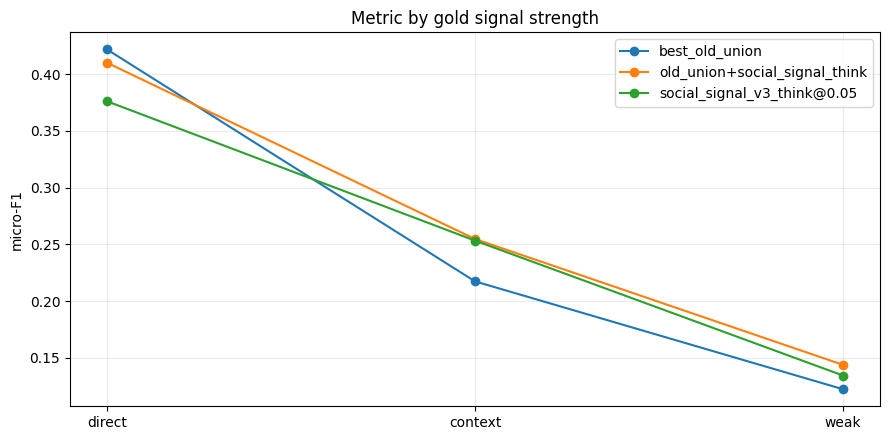

In [8]:
focus = strength_view[strength_view["config"].isin(["best_old_union", "social_signal_v3_think@0.05", "old_union+social_signal_think"])].copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
for config, sub in focus.groupby("config"):
    sub = sub.set_index("scope").loc[["direct", "context", "weak"]]
    ax.plot(sub.index, sub["micro_f1"], marker="o", label=config)
ax.set_ylabel("micro-F1")
ax.set_title("Metric by gold signal strength")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Per-Factor Behavior

In [9]:
per_factor = pd.read_csv(OUT / "v3_social_signal_final_per_factor_report.csv")
display(
    per_factor[per_factor["config"].eq("social_signal_v3_think@0.05")]
    .sort_values("support", ascending=False)
    .head(22)
    .round(4)
)
display(
    per_factor[per_factor["config"].eq("old_union+social_signal_think")]
    .sort_values("support", ascending=False)
    .head(22)
    .round(4)
)

,config,factor_key,support,predicted,precision,recall,f1,tp,fp,fn
65,social_signal_v3_think@0.05,industrial_production_index,130,102,0.8627,0.6769,0.7586,88,14,42
66,social_signal_v3_think@0.05,enterprises_count,100,8,0.7500,0.0600,0.1111,6,2,94
67,social_signal_v3_think@0.05,crime_count,73,45,0.8444,0.5205,0.6441,38,7,35
62,social_signal_v3_think@0.05,consumer_price_index,64,28,0.6071,0.2656,0.3696,17,11,47
44,social_signal_v3_think@0.05,life_expectancy,51,2,0.5000,0.0196,0.0377,1,1,50
48,social_signal_v3_think@0.05,real_income_index,47,1,1.0000,0.0213,0.0417,1,0,46
47,social_signal_v3_think@0.05,per_capita_income,40,0,0.0000,0.0000,0.0000,0,0,40
70,social_signal_v3_think@0.05,mortality_rate,26,15,0.7333,0.4231,0.5366,11,4,15
52,social_signal_v3_think@0.05,hospitals,20,5,0.8000,0.2000,0.3200,4,1,16
68,social_signal_v3_think@0.05,air_pollution,17,7,0.5714,0.2353,0.3333,4,3,13


,config,factor_key,support,predicted,precision,recall,f1,tp,fp,fn
101,old_union+social_signal_think,industrial_production_index,130,121,0.8264,0.7692,0.7968,100,21,30
102,old_union+social_signal_think,enterprises_count,100,41,0.8780,0.3600,0.5106,36,5,64
103,old_union+social_signal_think,crime_count,73,63,0.7778,0.6712,0.7206,49,14,24
98,old_union+social_signal_think,consumer_price_index,64,56,0.6429,0.5625,0.6000,36,20,28
80,old_union+social_signal_think,life_expectancy,51,14,0.7857,0.2157,0.3385,11,3,40
84,old_union+social_signal_think,real_income_index,47,3,0.6667,0.0426,0.0800,2,1,45
83,old_union+social_signal_think,per_capita_income,40,9,0.7778,0.1750,0.2857,7,2,33
106,old_union+social_signal_think,mortality_rate,26,25,0.6400,0.6154,0.6275,16,9,10
88,old_union+social_signal_think,hospitals,20,34,0.4118,0.7000,0.5185,14,20,6
104,old_union+social_signal_think,air_pollution,17,24,0.2083,0.2941,0.2439,5,19,12


In [10]:
compare = (
    per_factor[per_factor["config"].isin(["social_signal_v3_think@0.05", "old_union+social_signal_think"])]
    .pivot(index="factor_key", columns="config", values="f1")
    .join(per_factor.groupby("factor_key")["support"].max())
    .reset_index()
)
compare["delta"] = compare["old_union+social_signal_think"] - compare["social_signal_v3_think@0.05"]
compare.sort_values("delta", ascending=False).head(15).round(4)

,factor_key,old_union+social_signal_think,social_signal_v3_think@0.05,support,delta
30,primary_housing_price_index,1.0000,0.0000,1,1.0000
29,preschool_coverage,0.5000,0.0000,3,0.5000
9,enterprises_count,0.5106,0.1111,100,0.3995
15,internal_arrivals,0.3333,0.0000,3,0.3333
20,life_expectancy,0.3385,0.0377,51,0.3007
27,per_capita_income,0.2857,0.0000,40,0.2857
28,population_size,0.2500,0.0000,5,0.2500
6,consumer_price_index,0.6000,0.3696,64,0.2304
35,wastewater_discharge,0.6154,0.4000,16,0.2154
16,internal_departures,0.2000,0.0000,6,0.2000


## Sentiment Metrics

In [11]:
sentiment = pd.read_csv(OUT / "v3_social_signal_final_sentiment_metrics.csv")
sentiment.round(4)

,config,tp_pairs,sentiment_accuracy,sentiment_macro_f1
0,social_signal_v3_think@0.05,195,0.5128,0.4790
1,latent_v3@0.45,201,0.6468,0.6012
2,old_union+social_signal_think,313,0.5655,0.5264


## V5 Model Sweep

After the JSON repair parser and the shorter `social_signal_v5` prompt, the same evaluation set was
rerun with three local models:

- `gemma4:e2b`: original baseline model;
- `gemma4:e4b`: same family, larger model;
- `qwen3.5:9b`: larger alternative model.

This isolates prompt/model behavior from dataset and metric changes. All runs use `batch_size=1`,
`max_tokens=4096`, and no thinking mode.

In [12]:
model_sweep = pd.read_csv(OUT / "v3_social_signal_model_sweep_comparison_metrics.csv")
selected_configs = [
    "social_v5_e2b@default",
    "social_v5_gemma4_e4b@default",
    "social_v5_gemma4_e4b@0.60",
    "social_v5_qwen35_9b@default",
    "social_v5_qwen35_9b@0.40",
    "social_v5_qwen35_9b@0.60",
    "best_old_union",
    "old_union+social_v3_think@0.05",
    "gemma4_e4b@0.60 OR qwen35_9b@0.40",
    "grid_or_q0.60_g0.60",
]
(
    model_sweep[model_sweep["config"].isin(selected_configs)]
    .sort_values("micro_f1", ascending=False)
    [
        [
            "config",
            "pred_pairs",
            "mean_pred_labels",
            "precision",
            "recall",
            "micro_f1",
            "macro_f1_supported",
            "sample_f1",
            "any_f1",
            "false_relevant",
            "missed_all",
        ]
    ]
    .round(4)
)

,config,pred_pairs,mean_pred_labels,precision,recall,micro_f1,macro_f1_supported,sample_f1,any_f1,false_relevant,missed_all
0,grid_or_q0.60_g0.60,621,2.6203,0.6329,0.5991,0.6155,0.4220,0.5536,0.9577,7,12
8,gemma4_e4b@0.60 OR qwen35_9b@0.40,625,2.6371,0.6304,0.6006,0.6151,0.4211,0.5533,0.9577,7,12
21,social_v5_qwen35_9b@0.40,448,1.8903,0.7254,0.4954,0.5888,0.3495,0.5443,0.9425,3,22
22,social_v5_qwen35_9b@default,799,3.3713,0.5332,0.6494,0.5856,0.3934,0.5450,0.9784,10,0
24,social_v5_qwen35_9b@0.60,441,1.8608,0.7279,0.4893,0.5852,0.3494,0.5406,0.9425,3,22
25,social_v5_gemma4_e4b@0.60,480,2.0253,0.6750,0.4939,0.5704,0.3917,0.5182,0.9507,7,15
32,social_v5_gemma4_e4b@default,693,2.9241,0.5209,0.5503,0.5352,0.3713,0.4897,0.9784,10,0
34,old_union+social_v3_think@0.05,542,2.2869,0.5775,0.4771,0.5225,0.3595,0.4870,0.9784,10,0
35,best_old_union,468,1.9747,0.5705,0.4070,0.4751,0.3066,0.4439,0.9739,9,3
41,social_v5_e2b@default,260,1.0970,0.6615,0.2622,0.3755,0.1667,0.3757,0.9696,10,4


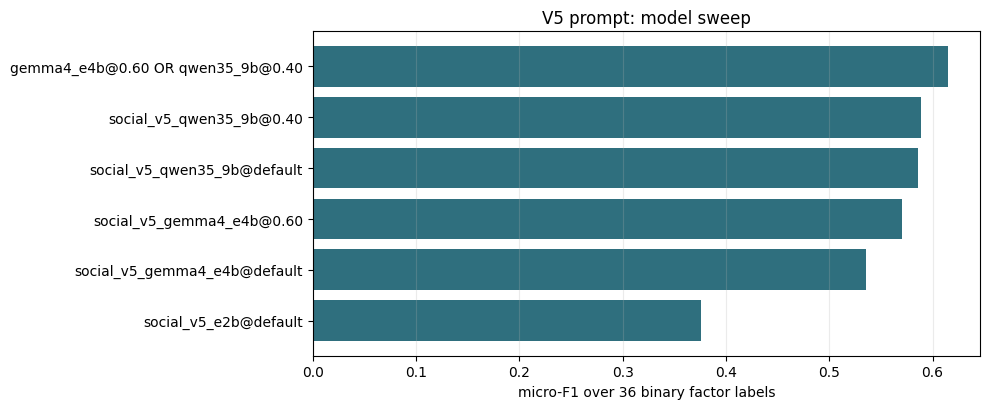

In [13]:
plot_configs = [
    "social_v5_e2b@default",
    "social_v5_gemma4_e4b@default",
    "social_v5_gemma4_e4b@0.60",
    "social_v5_qwen35_9b@default",
    "social_v5_qwen35_9b@0.40",
    "gemma4_e4b@0.60 OR qwen35_9b@0.40",
]
plot_df = model_sweep[model_sweep["config"].isin(plot_configs)].sort_values("micro_f1")
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(plot_df["config"], plot_df["micro_f1"], color="#2f6f7e")
ax.set_xlabel("micro-F1 over 36 binary factor labels")
ax.set_title("V5 prompt: model sweep")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## JSON Stability

In [14]:
raw_status = pd.read_csv(OUT / "v3_social_signal_model_sweep_raw_status.csv")
raw_status

,run,raw_calls,ok_calls,error_calls
0,social_v5_e2b,237,233,4
1,social_v5_gemma4_e4b,237,237,0
2,social_v5_qwen35_9b,237,237,0


The larger models changed the main failure mode. With `gemma4:e2b`, the short prompt was technically
better than previous long prompts, but still had a few JSON failures and returned too few factors.

With `gemma4:e4b` and `qwen3.5:9b`, JSON failures disappeared on this 237-news run. More importantly,
the models followed the "around 3 factors" prior much better.

## Threshold / Voting Search

In [15]:
grid = pd.read_csv(OUT / "v3_social_signal_model_sweep_grid_metrics.csv")
grid.head(12)[
    [
        "config",
        "mode",
        "q_threshold",
        "g_threshold",
        "pred_pairs",
        "mean_pred_labels",
        "precision",
        "recall",
        "micro_f1",
        "sample_f1",
        "any_f1",
        "missed_all",
    ]
].round(4)

,config,mode,q_threshold,g_threshold,pred_pairs,mean_pred_labels,precision,recall,micro_f1,sample_f1,any_f1,missed_all
0,grid_or_q0.60_g0.55,or,0.60,0.55,621,2.6203,0.6329,0.5991,0.6155,0.5536,0.9577,12
1,grid_or_q0.60_g0.60,or,0.60,0.60,621,2.6203,0.6329,0.5991,0.6155,0.5536,0.9577,12
2,grid_or_q0.55_g0.55,or,0.55,0.55,621,2.6203,0.6329,0.5991,0.6155,0.5536,0.9577,12
3,grid_or_q0.55_g0.60,or,0.55,0.60,621,2.6203,0.6329,0.5991,0.6155,0.5536,0.9577,12
4,grid_or_q0.40_g0.60,or,0.40,0.60,625,2.6371,0.6304,0.6006,0.6151,0.5533,0.9577,12
5,grid_or_q0.35_g0.55,or,0.35,0.55,625,2.6371,0.6304,0.6006,0.6151,0.5533,0.9577,12
6,grid_or_q0.40_g0.55,or,0.40,0.55,625,2.6371,0.6304,0.6006,0.6151,0.5533,0.9577,12
7,grid_or_q0.35_g0.60,or,0.35,0.60,625,2.6371,0.6304,0.6006,0.6151,0.5533,0.9577,12
8,grid_or_q0.50_g0.55,or,0.50,0.55,622,2.6245,0.6318,0.5991,0.6150,0.5534,0.9577,12
9,grid_or_q0.45_g0.60,or,0.45,0.60,622,2.6245,0.6318,0.5991,0.6150,0.5534,0.9577,12


The best simple voting setup is not the old ensemble. It is a two-model OR:
`qwen3.5:9b >= 0.60 OR gemma4:e4b >= 0.60`.

This reaches about `0.616` micro-F1 on the 237-news overlap. It is still not a final production
calibrator, because the thresholds were selected on this same overlap, but it is a real improvement
over the earlier prompt/model setup.

## Model-Sweep Signal Diagnostics

In [16]:
strength_sweep = pd.read_csv(OUT / "v3_social_signal_model_sweep_strength_metrics.csv")
strength_sweep[
    strength_sweep["config"].isin(
        [
            "social_v5_qwen35_9b@default",
            "social_v5_qwen35_9b@0.40",
            "social_v5_gemma4_e4b@0.60",
            "qwen35_0.60_OR_gemma4_0.60",
        ]
    )
].sort_values(["scope", "micro_f1"], ascending=[True, False]).round(4)

,scope,config,gold_pairs,pred_pairs,precision,recall,micro_f1
0,context,qwen35_0.60_OR_gemma4_0.60,259,621,0.2158,0.5174,0.3045
1,context,social_v5_qwen35_9b@0.40,259,448,0.2299,0.3977,0.2914
2,context,social_v5_gemma4_e4b@0.60,259,480,0.2188,0.4054,0.2842
3,context,social_v5_qwen35_9b@default,259,799,0.1840,0.5676,0.2779
7,direct,social_v5_qwen35_9b@0.40,243,448,0.4018,0.7407,0.5210
8,direct,qwen35_0.60_OR_gemma4_0.60,243,621,0.3076,0.7860,0.4421
9,direct,social_v5_gemma4_e4b@0.60,243,480,0.3292,0.6502,0.4371
12,direct,social_v5_qwen35_9b@default,243,799,0.2541,0.8354,0.3896
14,direct_context,social_v5_qwen35_9b@0.40,502,448,0.6317,0.5637,0.5958
15,direct_context,qwen35_0.60_OR_gemma4_0.60,502,621,0.5233,0.6474,0.5788


In [17]:
sentiment_sweep = pd.read_csv(OUT / "v3_social_signal_model_sweep_sentiment_metrics.csv")
sentiment_sweep.round(4)

,config,true_positive_factor_pairs,accuracy,macro_f1,weighted_f1
0,social_v5_gemma4_e4b@0.60,324,0.5772,0.5018,0.5186
1,social_v5_gemma4_e4b@default,361,0.5679,0.4952,0.5221
2,social_v5_e2b@default,172,0.5174,0.4725,0.5149
3,social_v5_qwen35_9b@default,426,0.5493,0.4699,0.5048
4,social_v5_qwen35_9b@0.40,325,0.5815,0.4638,0.5082


In [18]:
pf_sweep = pd.read_csv(OUT / "v3_social_signal_model_sweep_per_factor.csv")
(
    pf_sweep[(pf_sweep["config"].eq("qwen_default")) & (pf_sweep["support"] >= 10)]
    .sort_values("f1")
    .head(14)
    .round(4)
)

,config,factor_key,support,predicted,precision,recall,f1
84,qwen_default,international_inflow,10,53,0.1509,0.8000,0.2540
83,qwen_default,wastewater_discharge,16,4,1.0000,0.2500,0.4000
78,qwen_default,per_capita_income,40,26,0.5769,0.3750,0.4545
77,qwen_default,real_income_index,47,30,0.6333,0.4043,0.4935
79,qwen_default,mortality_rate,26,33,0.4545,0.5769,0.5085
81,qwen_default,air_pollution,17,10,0.7000,0.4118,0.5185
76,qwen_default,life_expectancy,51,62,0.5000,0.6078,0.5487
82,qwen_default,housing_area_per_capita,16,16,0.6250,0.6250,0.6250
75,qwen_default,consumer_price_index,64,108,0.5000,0.8438,0.6279
80,qwen_default,hospitals,20,27,0.5556,0.7500,0.6383


## Interpretation

The earlier low F1 was not just "bad data" and not just "broken JSON". Both mattered, but the larger
model sweep shows the main bottleneck was model/prompt following:

- `gemma4:e2b + v5` still averaged only about 1.1 predicted factors per news item and reached about
  `0.376` micro-F1.
- `gemma4:e4b + v5` followed the count prior much better, averaged about 2.9 factors at the default
  gate, and reached about `0.570` micro-F1 at a stricter threshold.
- `qwen3.5:9b + v5` was the best single-model run: about `0.586-0.589` micro-F1 depending on threshold,
  with default recall around `0.65`.
- simple two-model voting improved the main score to about `0.616` micro-F1.

The task is now behaving like a real multilabel weak-signal extraction problem. The remaining gap is
concentrated in weak/context links and several ambiguous factor definitions. Direct signals are much
easier; weak links are still noisy and require either expert relabeling, a verifier/reranker, or a
calibrated second-stage expansion.

Current best practical pipeline:
short social-signal prompt + batch size 1 + larger LLM + thresholded two-model voting + downstream
verifier for weak/context links.